# 9. Capstone: reproducible field screening

        Combine data cleaning, feature creation, grouping, ranking, visualization, and written
        limitations. A screening score organizes discussion; it is not an economic recommendation.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))


In [2]:
wells = pd.read_csv(ROOT / "data" / "synthetic_wells.csv")
required = ["porosity_fraction", "water_saturation_fraction", "permeability_md", "pressure_mpa", "oil_rate_bpd"]
assert wells[required].notna().all().all()
wells["flow_capacity_proxy"] = wells["permeability_md"] * wells["net_pay_m"]
for column in ["flow_capacity_proxy", "pressure_mpa", "oil_rate_bpd"]:
    low, high = wells[column].min(), wells[column].max()
    wells[column + "_scaled"] = (wells[column] - low) / (high - low)
wells["screening_score"] = (
    0.45 * wells["flow_capacity_proxy_scaled"]
    + 0.20 * wells["pressure_mpa_scaled"]
    + 0.35 * wells["oil_rate_bpd_scaled"]
)
ranking = wells.sort_values("screening_score", ascending=False)
ranking[["well_id", "field", "screening_score", "permeability_md", "net_pay_m", "oil_rate_bpd"]].head(10)


,well_id,field,screening_score,permeability_md,net_pay_m,oil_rate_bpd
18,W-19,Central,0.774202,75.74,23.53,254.6
11,W-12,Central,0.755597,63.98,25.90,253.8
28,W-29,North,0.707765,61.15,25.31,226.3
20,W-21,North,0.703663,58.29,25.68,260.6
2,W-03,South,0.689694,72.48,19.92,309.4
25,W-26,South,0.670509,49.38,26.62,285.8
0,W-01,North,0.635416,82.25,13.49,335.1
9,W-10,South,0.598395,64.90,11.61,304.1
7,W-08,Central,0.580623,72.73,15.73,246.9
6,W-07,South,0.578522,68.07,20.23,229.2


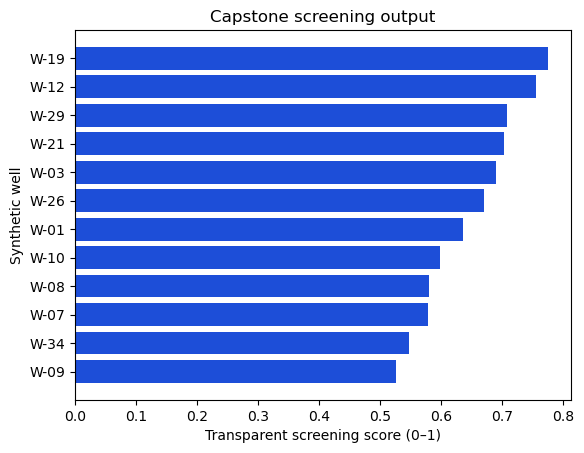

In [3]:
top = ranking.head(12).sort_values("screening_score")
plt.barh(top["well_id"], top["screening_score"], color="#1d4ed8")
plt.xlabel("Transparent screening score (0–1)")
plt.ylabel("Synthetic well")
plt.title("Capstone screening output")
plt.show()


## Deliverable

        Write five sentences: objective, dataset provenance, method, main result, and limitations.
        Identify at least three missing inputs required before any field decision.